### SUPPORT VECTOR MACHINES

- Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression
- <u>MARGIN</u>(d) is defined as the maximum distance between the hyperplane and the nearest data points of each class, called support vectors.

<img src= "svmMARGIN.png" width=400/>

- <u>HYPERPLANE</u> is a line/plane that seperates classes
The decision boundary equation is:

$$
\mathbf{w} \cdot \mathbf{x} + b = 0
$$

Where:

- $\mathbf{w}$ : Weight vector  
- $\mathbf{x}$ : Feature vector  
- $b$ : Bias (intercept)  
- $\mathbf{w} \cdot \mathbf{x}$ : Dot product (linear score)

<img src= "svmMath.png" width=400/>

ADVANTAGES:
- Maximses margin 
- Effective in high-dimensional spaces (suitable when features are more than samples)
- Uses only support vectors
- Handles non-linear data (uses KERNEL functions to model complex decision boundaries)


SVM constraints ensure that:

- Data points are classified correctly

- Points stay outside or on the margin

- Margin violations (if allowed) are controlled

<b>Constraint for correct classification (core constraint) :</b>
For every training point ($x_i,y_i$)
$$
y_i \left( \mathbf{w} \cdot \mathbf{x}_i + b \right) \ge 1
$$

if $y_i$ = +1 -> point lies on or beyond the positive margin

if $y_i$ = -1 -> point lies on or beyond the negative margin

*Ensure no point is inside the margin* 

therefore, The margin of the SVM is defined as:

$$
\text{Margin} = \frac{2}{\|\mathbf{w}\|}
$$

Where:

- $\mathbf{w}$ : Weight vector
- $\|\mathbf{w}\|$ : Euclidean norm (length) of the weight vector



#### Errors in SVM:
##### Margin error:

- A data point is correctly classified

- BUT it lies inside the margin

- It violates the margin constraint

- The point is on the correct side of the hyperplane

- But it is too close to the decision boundary

- SVM allows this to keep the model robust

##### Misclassification error: 

- A data point is classified incorrectly

- It lies on the wrong side of the hyperplane

- Allowed only in Soft Margin SVM

#### <u>Hard Margin SVM :</u>

Hard Margin SVM is used when the data is perfectly linearly separable, and it does not allow any misclassification or margin violation.

<img src= "hardmargin.webp" width=400/>

constraint used is : 
$$
y_i \left( \mathbf{w} \cdot \mathbf{x}_i + b \right) \ge 1
$$

All points must lie outside the margin

No point can be:

- inside the margin

- misclassified

Intuition

- Draws a strict boundary

- Even one noisy point can break the model

- Very sensitive to outliers

*RARE IN REAL WORLD DATA*

#### <u>Soft Margin SVM: </u>

Soft Margin SVM allows some margin violations and misclassifications to handle noisy and overlapping data, using slack variables.

<img src='softmargin.png' width=400/>

The soft-margin SVM constraints are:

$$
y_i \left( \mathbf{w} \cdot \mathbf{x}_i + b \right) \ge 1 - \xi_i
$$

$$
\xi_i \ge 0
$$

Where:

- $\xi_i = 0$ → correctly classified and outside the margin  
- $0 < \xi_i < 1$ → correctly classified but inside the margin  
- $\xi_i > 1$ → misclassified sample

Slack variables (denoted as $ξ_i$(zeta_i)) are non-negative variables introduced in Soft Margin SVM to measure how much a data point violates the margin constraint.

Real-world data:

is noisy

is overlapping

is not perfectly separable

👉 Hard Margin SVM fails here.

Slack variables allow:

some points inside the margin

some misclassified points

while still keeping a large margin


##### C Parameter in SVM:
C is the regularization parameter in Soft Margin SVM that controls the trade-off between maximizing the margin and minimizing classification errors.

- Large C → strict teacher → no mistakes allowed

- Small C → lenient teacher → some mistakes allowed

The optimization problem for soft-margin SVM is:

$$
\min_{\mathbf{w},\, b,\, \xi}
\;\; \frac{1}{2}\|\mathbf{w}\|^2
+ C \sum_{i=1}^{n} \xi_i
$$

Where:

- $\mathbf{w}$ : Weight vector
- $b$ : Bias term
- $\xi_i$ : Slack variable for the $i^{th}$ sample
- $n$ : Number of training samples
- $C$ : Regularization parameter
- $\frac{1}{2}\|\mathbf{w}\|^2$ : Margin maximization term
- $C \sum \xi_i$ : Penalty for margin violations



##### Hinge loss in SVM:
A loss that penalizes points that are misclassified or lie within the margin; it encourages a large margin while tolerating some violations.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
inputs=df.drop('species',axis=1)
target=df['species']

In [4]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
target=encoder.fit_transform(target)
target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
df['target']= target
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,target
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


In [6]:
df0=df[target==0]
df1=df[target==1]
df2=df[target==2]

In [7]:
df0.head()

,sepal_length,sepal_width,petal_length,petal_width,species,target
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


Text(0, 0.5, 'sepal_width')

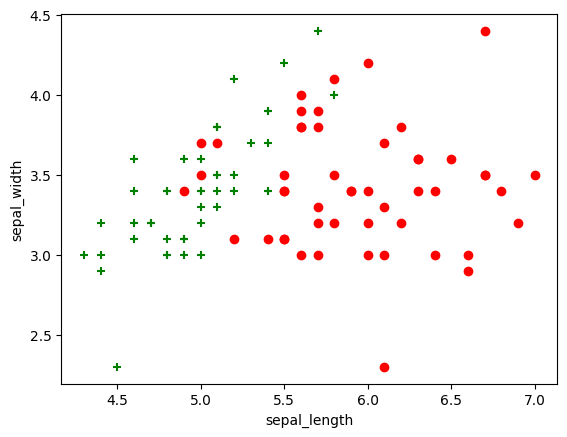

In [8]:
plt.scatter(df0['sepal_length'],df0['sepal_width'],color='green',marker='+')
plt.scatter(df1['sepal_length'],df0['sepal_width'],color='red',marker='o')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')

Text(0, 0.5, 'petal_width')

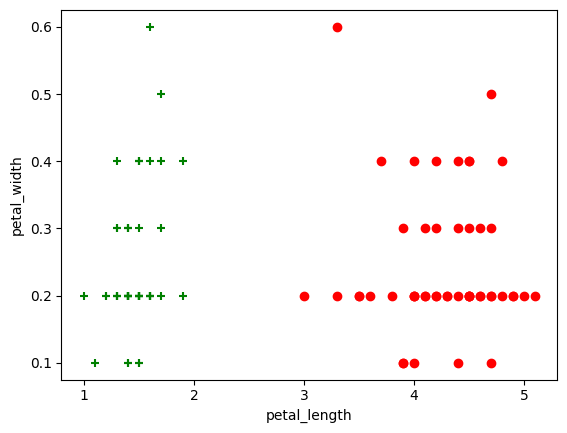

In [9]:
plt.scatter(df0['petal_length'],df0['petal_width'],color='green',marker='+')
plt.scatter(df1['petal_length'],df0['petal_width'],color='red',marker='o')
plt.xlabel('petal_length')
plt.ylabel('petal_width')

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train,X_test,y_train,y_test=train_test_split(inputs,target,test_size=0.2,random_state=2)

In [12]:
len(X_train)

120

In [13]:
from sklearn.svm import SVC
model=SVC(kernel='linear',C=1)
#kernel='linear' → Linear SVM

#C=1 → balanced margin vs error

In [14]:
model.fit(X_train,y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [15]:
model.score(X_test,y_test)

1.0

In [16]:
y_pred=model.predict(X_test)


In [17]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [18]:
print("Accuracy : ",accuracy_score(y_test,y_pred))
print("Confusion matrix : \n",confusion_matrix(y_test,y_pred))

Accuracy :  1.0
Confusion matrix : 
 [[14  0  0]
 [ 0  8  0]
 [ 0  0  8]]


In [19]:
model.support_vectors_

array([[5.1, 3.3, 1.7, 0.5],
       [5.4, 3. , 4.5, 1.5],
       [5.1, 2.5, 3. , 1.1],
       [6.3, 3.3, 4.7, 1.6],
       [6.8, 2.8, 4.8, 1.4],
       [6.9, 3.1, 4.9, 1.5],
       [5.6, 3. , 4.5, 1.5],
       [6. , 2.7, 5.1, 1.6],
       [5.9, 3.2, 4.8, 1.8],
       [6.2, 2.2, 4.5, 1.5],
       [6.1, 2.9, 4.7, 1.4],
       [6.3, 2.5, 4.9, 1.5],
       [6.2, 2.8, 4.8, 1.8],
       [4.9, 2.5, 4.5, 1.7],
       [6. , 2.2, 5. , 1.5],
       [6.3, 2.7, 4.9, 1.8],
       [6.3, 2.5, 5. , 1.9],
       [6.5, 3. , 5.2, 2. ],
       [5.9, 3. , 5.1, 1.8],
       [6.3, 2.8, 5.1, 1.5],
       [6.5, 3.2, 5.1, 2. ],
       [6. , 3. , 4.8, 1.8]])

In [20]:
model.n_support_

array([ 1, 11, 10], dtype=int32)

#### KERNEL TRICK

If data isn’t linearly separable, SVM can use a kernel to implicitly map inputs into a higher-dimensional space where a linear separator may exist.

Kernel: The kernel function used to transform the data into a higher-dimensional space. Common kernels include 'linear', 'poly', and 'rbf'.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from matplotlib.colors import ListedColormap
from sklearn.datasets._samples_generator import make_circles

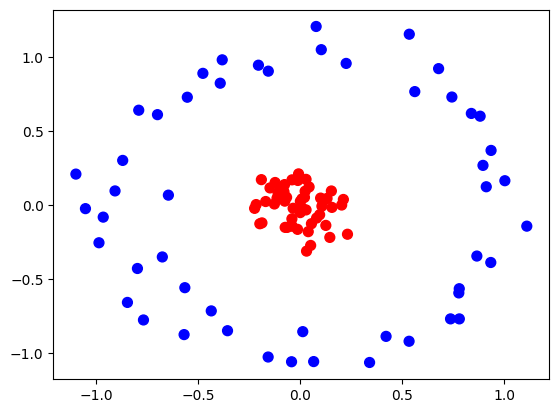

In [22]:
X,y= make_circles(100,factor=.1,noise=0.1)
plt.scatter(X[:,0],X[:,1],c=y,s=50,cmap='bwr')

In [23]:
X_train1,X_test1,y_train1,y_test1=train_test_split(X,y,test_size=0.2)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler1=StandardScaler()

In [25]:
X_train1=scaler1.fit_transform(X_train1)
X_test1=scaler1.transform(X_test1)

In [26]:
model.fit(X_train1,y_train1.ravel())
y_pred1=model.predict(X_test1)

In [27]:
accuracy_score(y_test1,y_pred1)

0.4

In [28]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

zero_one_colormap = ListedColormap(('blue', 'red'))

def plot_decision_boundary(X, y, clf):
    # 🔒 Ensure NumPy arrays (prevents Pandas indexing errors)
    X_set = np.asarray(X)
    y_set = np.asarray(y)

    # ✅ FIX 1: meshgrid needs TWO ranges
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1,
                  stop=X_set[:, 0].max() + 1,
                  step=0.01),
        np.arange(start=X_set[:, 1].min() - 1,
                  stop=X_set[:, 1].max() + 1,
                  step=0.01)
    )

    # Decision region
    plt.contourf(
        X1, X2,
        clf.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(X1.shape),
        alpha=0.75,
        cmap=zero_one_colormap
    )

    # ✅ FIX 2: remove invalid argument "colors"
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())

    # Plot data points
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            c=[zero_one_colormap(i)],
            label=j,
            edgecolors='k'
        )

    plt.title("SVM Decision Boundary")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.legend()
    plt.show()


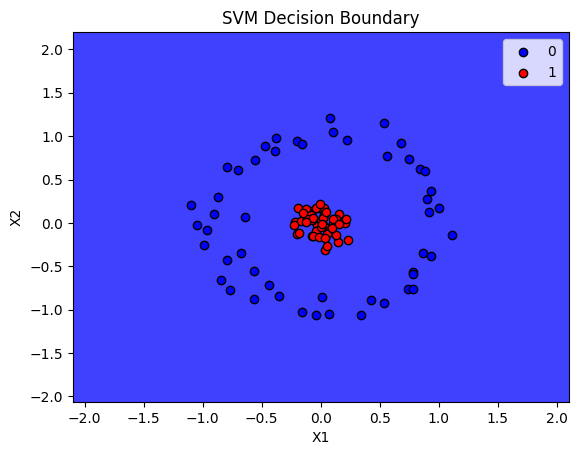

In [29]:
plot_decision_boundary(X,y,model)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_plot(x, y):
    # r calculation
    r = np.exp(-(x**2).sum(1))

    # Create 3D axis
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    # 3D scatter plot
    ax.scatter3D(x[:, 0], x[:, 1], r, c=y, s=100, cmap="bwr")

    # Axis labels
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('y')

    plt.show()
    return ax


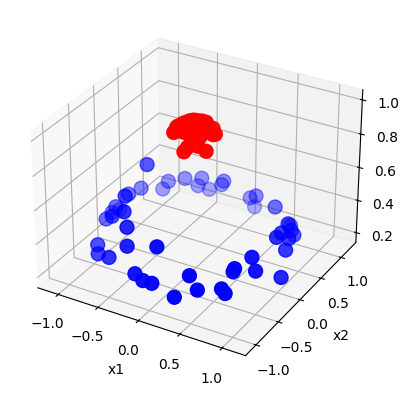

<Axes3D: xlabel='x1', ylabel='x2', zlabel='y'>

In [31]:
plot_3d_plot(X,y)

In [32]:
rbf_model= SVC(kernel='rbf')
rbf_model.fit(X_train1,y_train1)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


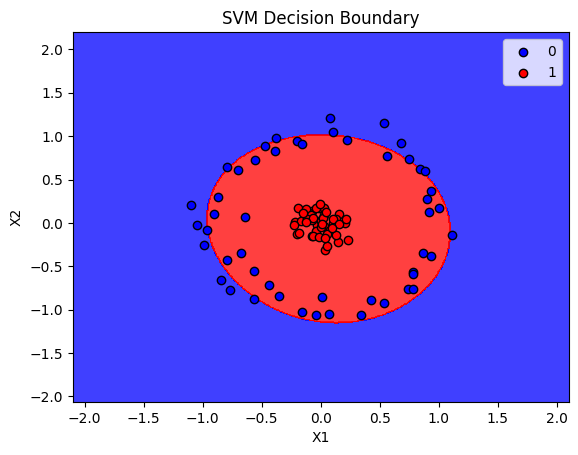

In [33]:
plot_decision_boundary(X,y,rbf_model)